# Summer '26
## Author: Zane Collins
## Last Updated: 06/17/2026


# Imports

In [2]:
from hapi import *

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

from scipy.signal import correlate
from scipy.signal import convolve

%matplotlib widget

# Parsing

In [3]:
db_begin("HAPI_DB");

Using HAPI_DB

CH4
                     Lines parsed: 9009
CH4_iso2
                     Lines parsed: 79200
H2O_iso3
                     Lines parsed: 10441
H2O_iso1
                     Lines parsed: 53108
CH4_iso1
                     Lines parsed: 194110
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 14038


In [4]:
tableList()

dict_keys(['sampletab', 'CH4', 'CH4_iso2', 'H2O_iso3', 'H2O_iso1', 'CH4_iso1', 'H2O', 'H2O_iso2'])

In [5]:
wn_min = 4000
wn_max = 7100


## CH4 & Water Fetching

In [6]:
# Isotopes to download:
ch4_isotopes = [1,2]
h2o_isotopes = [1,2,3]

In [ ]:
for isotope in ch4_isotopes:
    fetch(f"CH4_iso{isotope}", 6, isotope, wn_min, wn_max)
for isotope in h2o_isotopes:
    fetch(f"H2O_iso{isotope}", 1, isotope, wn_min, wn_max)


Data is fetched from http://hitran.org

BEGIN DOWNLOAD: CH4_iso1
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1

# Helper Functions

In [ ]:
def compute_transmission(molecule, isotope, dwn, T = 288, p = 1, column_density = 1e12, path_length = 1e5,scale_factor = 1.0):

    #Check if the molecule and isotope are in the database
    table_name = f"{molecule}_iso{isotope}"
    # if table_name not in [t[0] for t in tableList()]:
    #     raise ValueError(f"{molecule} with isotope {isotope} not found in database. Table {table_name}")
    
    #Fetch the absorption coefficients for the specified molecule and isotope
    wn_grid, coef = absorptionCoefficient_Voigt(
            Components=[(6, isotope, 1)],
            SourceTables=table_name,
            WavenumberRange=(wn_min, wn_max),
            WavenumberStep=dwn,
            Environment={'T': T, 'p': p} 
        )
    
    # Calculate the transmission using the Beer-Lambert law
    tau = coef * column_density * path_length

    tau *= scale_factor

    transmission = np.exp(-tau)

    wavelength_grid = 1e4 / wn_grid
    resolution = np.median(wn_grid) / dwn

    return wavelength_grid, transmission, resolution

def generate_res_isotope_dict(molecules,isotopes,dwn, T = 288, p = 1, column_density = 1e12, path_length = 1e5, scale_factor = 1.0):
    dict = {}
    resolution = np.median(np.arange(wn_min, wn_max, dwn)) / dwn
    print(f"Resolution: {resolution}")
    res_key = int(round(resolution))
    dict[res_key] = {} #Initialize an empty dictionary to store results for each isotope 
    for mol in molecules:
        dict[res_key][mol] = {}
        for isotope in isotopes:
            dict[res_key][mol][isotope] = {}
            wavelength_grid, transmission, resolution = compute_transmission(mol, isotope, dwn, T, p, column_density, path_length, scale_factor)
            print(f"Resolution for {mol} iso {isotope}: {resolution}")
            dict[res_key][mol][isotope] = (wavelength_grid, transmission, resolution)
    return dict

def create_combined_transmission(data_dict, molecule_abundances, resolution, T=None, p=None, scale_factor=None):
    """
    molecule_abundances: dict[molecule] = dict[isotope] = fractional abundance (or column density scaling)
    Example: {'CH4': {1: 0.8, 2: 0.2}, 'H2O': {1: 1.0}}
    """
    tau_total = None
    wl_grid = None
    
    for mol, iso_abund in molecule_abundances.items():
        for iso, frac in iso_abund.items():
            try:
                data = data_dict[resolution][mol][iso]
                current_wl = data[0]
                trans = data[1]
            except KeyError:
                print(f"Missing data for {mol} iso {iso}")
                continue
                
            if wl_grid is None:
                wl_grid = current_wl
            
            tau = -np.log(np.clip(trans, 1e-10, 1.0))  # avoid log(0), tau = -ln(T) = -ln(exp(-tau)) = tau
            tau_total = tau * frac if tau_total is None else tau_total + tau * frac # Sum the optical depths weighted by their fractional abundances
    
    if tau_total is None:
        raise ValueError("No data found for any species")
    
    combined_trans = np.exp(-tau_total)
    return wl_grid, combined_trans

def convolve_to_resolution(wavelength_grid, transmission, target_resolution, trim_edges=True):
    """
    Convolve the transmission spectrum to a target resolution using a Gaussian kernel.

    in: wavelength_grid: array of wavelengths
        transmission: array of transmission values corresponding to the wavelength grid
        target_resolution: desired spectral resolution (lambda/delta_lambda)

    out: convolved_transmission: transmission spectrum convolved to the target resolution
         convolved_wavelength_grid: wavelength grid corresponding to the convolved transmission spectrum
         
    """

    wl_grid = np.array(wavelength_grid)
    

    #convert target resolution to fwhm
    lambda_mid = np.mean(wl_grid)
    FWHM = lambda_mid / target_resolution
    
    sigma_lambda = FWHM / (2 * np.sqrt(2 * np.log(2)))  # since fwhm is proportional to sigma by FWHM = 2*sqrt(2*ln(2))*sigma, convert fwhm to sigma
    
    #create gaussian kernel
    kernel_width = max(31,int(8*sigma_lambda) * 2 + 1)  # ensure kernel width is odd (for symmetric convolution), covering ±3 sigma
    x = np.arange(-kernel_width//2, kernel_width//2 + 1)
    
    kernel = np.exp(-0.5 * (x / sigma_lambda)**2) #gaussian kernel array
    kernel /= kernel.sum()   # normalize
    
    # Convolve the transmission with the Gaussian kernel
    convolved_transmission = convolve(transmission, kernel, mode='same')
    # print(f"Convolved transmission min: {convolved_transmission.min():.4e}, max: {convolved_transmission.max():.4e}")

    #Must trim the bad edges of the convolved spectrum to avoid artifacts from convolution (Kernel extends beyond the edges of the data)
    if trim_edges:
        convolved_transmission = convolved_transmission[10:-10]
        wavelength_grid = wavelength_grid[10:-10]

    return wavelength_grid, convolved_transmission

# Noise injection
def inject_poisson_noise(data, SNR):

    signal = np.average(data)  # Representative signal level for scaling noise
    print(f"Average signal level: {signal:.4e}")
    scale = signal / SNR if signal > 0 else 1.0 
    print(f"scale factor: {scale:.4e} for SNR={SNR}")

    poisson_noise = np.random.poisson(lam=data)
    poisson_noise = poisson_noise - data  # Center the noise around zero
    
    noisy_data = data + poisson_noise * scale / np.sqrt(signal)  # Scale noise by SNR and signal level
    noisy_data = np.clip(noisy_data, 0, None)  # Ensure non-negative values

    errorbars = np.sqrt(data) * scale / np.sqrt(signal)  # Poisson noise error bars

    return noisy_data, errorbars

def inject_gaussian_noise(data, SNR, seed = 8):

    depth = 1.0 - data          # or np.abs(1.0 - data) if baseline isn't exactly 1
    signal_level = np.max(depth)   # Peak depth
    # signal_level = np.sqrt(np.mean(depth**2))   # RMS depth
    
    sigma = signal_level / SNR
    # print(f"Signal level: {signal_level:.4e}, Noise std dev: {sigma:.4e} for SNR={SNR}")

    nchan = len(data)
    rng = np.random.default_rng(seed)

    random_pertubations = sigma*rng.standard_normal(nchan)
    # print(f"Actual noise std: {random_pertubations.std():.4e} | Max |noise|: {np.abs(random_pertubations).max():.4e}")

    


    synthetic_atmosphere = data + random_pertubations 
    synthetic_atmosphere = np.clip(synthetic_atmosphere, 0, None) 
    
    errorbars = np.full_like(data, sigma) 
    return synthetic_atmosphere, errorbars




# Test

In [ ]:
dwns = [0.01]
ch4_isos = [1,2]
h2o_isos = [1]

data_dict = generate_res_isotope_dict(['CH4','H2O'], ch4_isos, dwns, T=288, p=1, column_density=1e12, path_length=1e5, scale_factor=5.0)

{'air': 1.0}
46.900036 seconds elapsed for abscoef; nlines = 194110
{'air': 1.0}
15.395753 seconds elapsed for abscoef; nlines = 79200
{'air': 1.0}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/hapi/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


42.383859 seconds elapsed for abscoef; nlines = 194110
{'air': 1.0}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/hapi/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


14.766409 seconds elapsed for abscoef; nlines = 79200
{'air': 1.0}
1.330375 seconds elapsed for abscoef; nlines = 53108
{'air': 1.0}
0.382628 seconds elapsed for abscoef; nlines = 14038
{'air': 1.0}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/hapi/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


1.399282 seconds elapsed for abscoef; nlines = 53108
{'air': 1.0}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/hapi/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


0.329891 seconds elapsed for abscoef; nlines = 14038


In [313]:
test_molecule_abundances = {'CH4': {1: 1, 2: 1}, 'H2O': {1: 10.0}}
wl_grid, combined_trans = create_combined_transmission(data_dict, test_molecule_abundances, dwn=0.1, T=288, p=1)

In [314]:
print(data_dict['CH4'][0.1][1][2])

55500.0


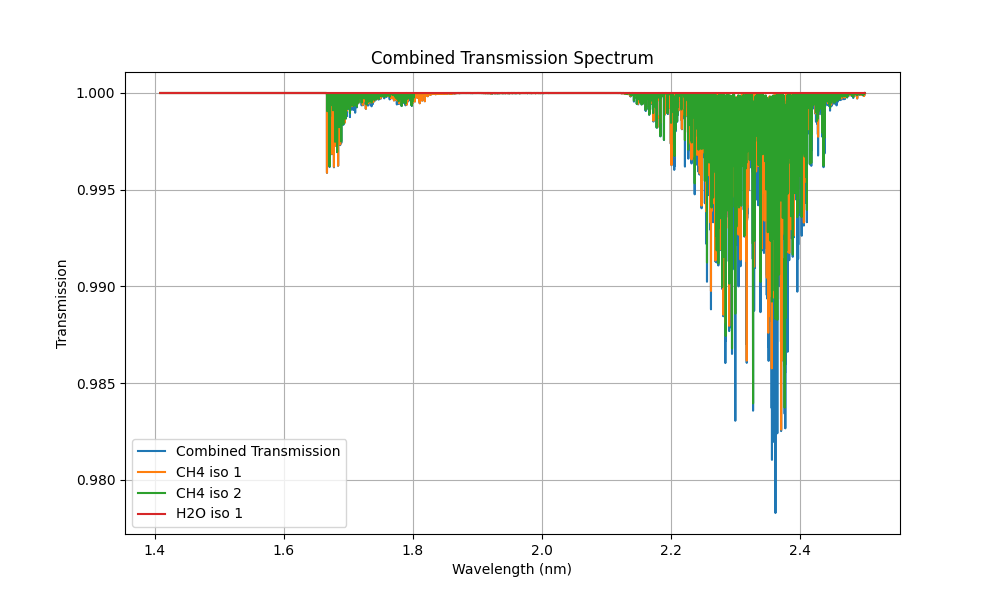

In [315]:
plt.figure(figsize=(10, 6))
plt.plot(wl_grid, combined_trans, label='Combined Transmission')
plt.plot(data_dict['CH4'][0.1][1][0], data_dict['CH4'][0.1][1][1], label='CH4 iso 1')
plt.plot(data_dict['CH4'][0.1][2][0], data_dict['CH4'][0.1][2][1], label='CH4 iso 2')
plt.plot(data_dict['H2O'][0.1][1][0], data_dict['H2O'][0.1][1][1], label='H2O iso 1')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Combined Transmission Spectrum')
plt.legend()
plt.grid()

In [316]:
noisy_combined = {}

snr_values = [1,5, 10, 50, 100, 1000]

for snr in snr_values:
    key = f"SNR_{snr}"
    noisy_combined[key] = {}
    
    # Generate noise per SNR
    noisy_trans, error_bars = inject_gaussian_noise(combined_trans, snr)
    
    noisy_combined[key]['Transmission'] = noisy_trans
    noisy_combined[key]['ErrorBars']    = error_bars          
    noisy_combined[key]['wl_grid']      = wl_grid.copy() 

# Cross Correlation Tests

## Test - CH4 Isotopologue Detection

In [92]:
dwn = 0.01
ch4_isos = [1,2]

parent_dict = generate_res_isotope_dict(['CH4'], ch4_isos, dwn, T=288, p=1, column_density=1e12, path_length=1e5, scale_factor=5.0)

resolution = np.median(np.arange(wn_min, wn_max, dwn)) / dwn
res_key = int(round(resolution))
print(res_key)

Resolution: 554999.5000033833
{'air': 1.0}
94.090940 seconds elapsed for abscoef; nlines = 194110
Resolution for CH4 iso 1: 555000.0
{'air': 1.0}
29.664660 seconds elapsed for abscoef; nlines = 79200
Resolution for CH4 iso 2: 555000.0
555000


In [ ]:
# Convolve for target resolution
resolutions = [100, 500, 1000, 5000, 10000]

print("Keys in dict:", list(parent_dict.keys()))   # confirm

data_dict = {}   # new dict for convolved versions

for res in resolutions:
    for res_key in parent_dict.keys():          # should be 555000
        for mol in parent_dict[res_key].keys():
            for iso in parent_dict[res_key][mol].keys():
                
                data = parent_dict[res_key][mol][iso]
                
                wl_grid = data[0]
                trans = data[1]
                
                # Convolve to desired target resolution
                # print(f"Convolving {mol} iso {iso} from res {res_key} to target res {res}")
                wl_conv, trans_conv = convolve_to_resolution(wl_grid, trans, res)
                
                # Store
                if res not in data_dict:
                    data_dict[res] = {}
                if mol not in data_dict[res]:
                    data_dict[res][mol] = {}
                
                data_dict[res][mol][iso] = {
                    'wavelength_grid': wl_conv,
                    'transmission': trans_conv,
                    'resolution': res
                }

print("Convolved resolutions created:", list(data_dict.keys()))

Keys in dict: [555000]
Convolving CH4 iso 1 from res 555000 to target res 100
Convolved transmission min: 0.0000e+00, max: 1.0000e+00
Convolving CH4 iso 2 from res 555000 to target res 100
Convolved transmission min: 0.0000e+00, max: 1.0000e+00
Convolving CH4 iso 1 from res 555000 to target res 500
Convolved transmission min: 0.0000e+00, max: 1.0000e+00
Convolving CH4 iso 2 from res 555000 to target res 500
Convolved transmission min: 0.0000e+00, max: 1.0000e+00
Convolving CH4 iso 1 from res 555000 to target res 1000
Convolved transmission min: 0.0000e+00, max: 1.0000e+00
Convolving CH4 iso 2 from res 555000 to target res 1000
Convolved transmission min: 0.0000e+00, max: 1.0000e+00
Convolving CH4 iso 1 from res 555000 to target res 5000
Convolved transmission min: 0.0000e+00, max: 1.0000e+00
Convolving CH4 iso 2 from res 555000 to target res 5000
Convolved transmission min: 0.0000e+00, max: 1.0000e+00
Convolving CH4 iso 1 from res 555000 to target res 10000
Convolved transmission min: 

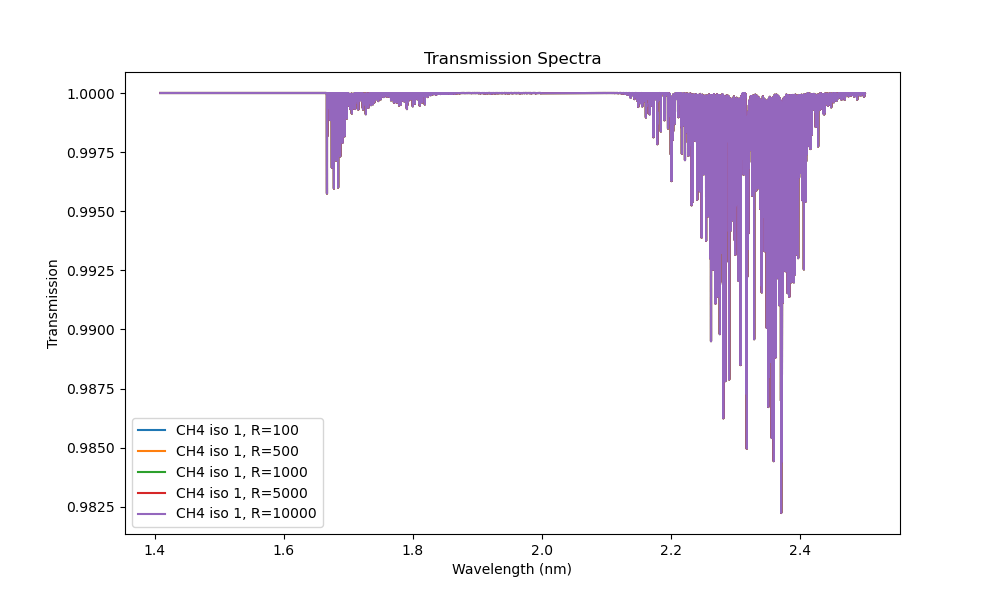

In [96]:
plt.close('all')  # Close any existing figures

plt.figure(figsize=(10, 6))
# plt.plot(parent_dict[555000]['CH4'][1][0], parent_dict[555000]['CH4'][1][1], label='CH4 iso 1, R=555000')
for res in resolutions:
    plt.plot(data_dict[res]['CH4'][1]['wavelength_grid'], data_dict[res]['CH4'][1]['transmission'], label=f'CH4 iso 1, R={res}')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Transmission Spectra')
plt.legend()
plt.show()

In [318]:
test_molecule_abundances = {'CH4': {1: 0.95, 2: 1e-5}}
combined_dict = {}

for dwn in dwns:
    combined_dict[dwn] = {}
    wl_grid, combined_trans = create_combined_transmission(data_dict, test_molecule_abundances, dwn=dwn, T=288, p=1)
    combined_dict[dwn]['wl_grid'] = wl_grid
    combined_dict[dwn]['combined_trans'] = combined_trans


### Noisify

In [319]:
noisy_combined = {}

snr_values = [1,5, 10, 50, 100, 500]

for dwn in dwns:
    noisy_combined[dwn] = {}
    for snr in snr_values:
        key = f"SNR_{snr}"
        noisy_combined[dwn][key] = {}
        combined_trans= combined_dict[dwn]['combined_trans']
        wl_grid = combined_dict[dwn]['wl_grid']
        
        # Generate noise per SNR
        noisy_trans, error_bars = inject_gaussian_noise(combined_trans, snr)    
        noisy_combined[dwn][key]['Transmission'] = noisy_trans
        noisy_combined[dwn][key]['ErrorBars']    = error_bars          
        noisy_combined[dwn][key]['wl_grid']      = wl_grid.copy()

## Cross-Correlate

In [320]:
# dwn_cc = 0.1
isotope_cc = 2


In [321]:
results = []

for dwn in noisy_combined:
    for snr in noisy_combined[dwn]:

        # print(f"Processing dwn={dwn} cm⁻¹, SNR={snr}")
        parent_spectra = data_dict['CH4'][dwn][isotope_cc][1]
        wl_grid_cc=wl_grid.copy()  # Ensure wl_grid is defined for this scope
        
        test_data = noisy_combined[dwn][snr]
        test_spectra = test_data['Transmission']
        
        parent_norm = (parent_spectra - np.mean(parent_spectra)) / np.std(parent_spectra) # Zero Mean Cross Correlation
        test_norm   = (test_spectra   - np.mean(test_spectra))   / np.std(test_spectra)
        
        correlation = correlate(parent_norm, test_norm, mode='same')
        correlation /= np.sqrt(np.sum(parent_norm**2) * np.sum(test_norm**2))  # Normalize to max correlation of 1
        
        max_corr = (correlation[len(correlation)//2])

        # SNR and resolution results
        cc_snr = max_corr / np.std(correlation) if np.std(correlation) > 0 else 0
        cc_uncertainty = np.std(correlation)
        resolution = 1e4 / dwn

        results.append({
            'dwn': dwn,
            'snr': snr,
            'max_correlation': max_corr,
            'resolution': resolution,
            'cc_snr': cc_snr,
            'cc_uncertainty': cc_uncertainty
        })

In [323]:
df = pd.DataFrame(results)
df

,dwn,snr,max_correlation,resolution,cc_snr,cc_uncertainty
0,10.00,SNR_1,0.008483,1000.0,0.187897,0.045147
1,10.00,SNR_5,0.129701,1000.0,2.112904,0.061385
2,10.00,SNR_10,0.228076,1000.0,2.850635,0.080009
3,10.00,SNR_50,0.361544,1000.0,3.419263,0.105737
4,10.00,SNR_100,0.373668,1000.0,3.473793,0.107568
...,...,...,...,...,...,...
61,0.01,SNR_5,0.052816,1000000.0,3.745309,0.014102
62,0.01,SNR_10,0.101944,1000000.0,3.789662,0.026900
63,0.01,SNR_50,0.256426,1000000.0,3.818869,0.067147
64,0.01,SNR_100,0.280483,1000000.0,3.822126,0.073384


## Plotting Spectra

In [328]:
snr_to_plot = 10
dwn_to_plot = 10
isotope_to_plot = 2

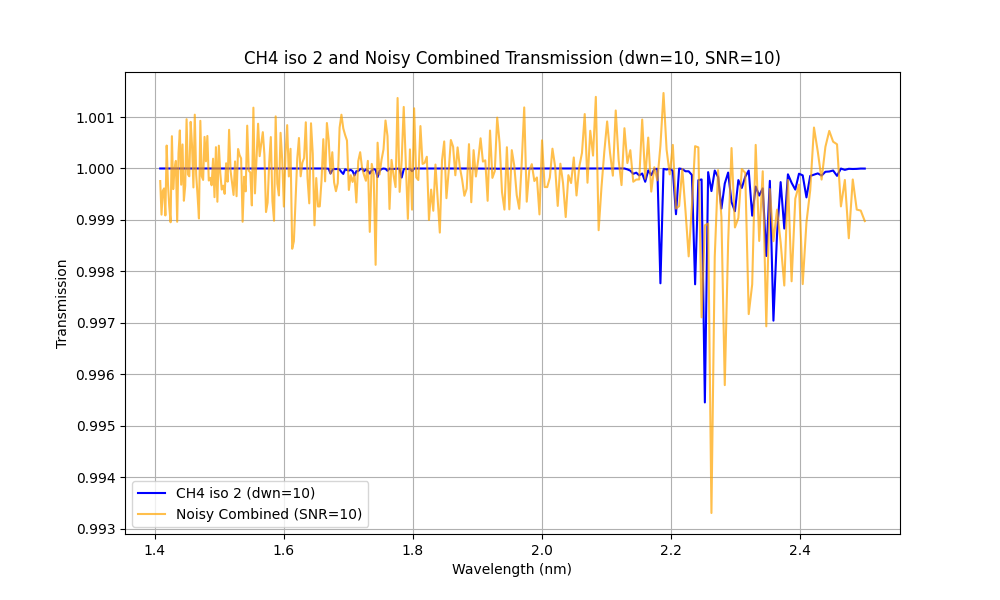

In [329]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(data_dict['CH4'][dwn_to_plot][isotope_to_plot][0], data_dict['CH4'][dwn_to_plot][isotope_to_plot][1], label=f'CH4 iso {isotope_to_plot} (dwn={dwn_to_plot})', color='blue')
plt.plot(noisy_combined[dwn_to_plot][f'SNR_{snr_to_plot}']['wl_grid'], noisy_combined[dwn_to_plot][f'SNR_{snr_to_plot}']['Transmission'], label=f'Noisy Combined (SNR={snr_to_plot})', color='orange', alpha = 0.7)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title(f'CH4 iso {isotope_to_plot} and Noisy Combined Transmission (dwn={dwn_to_plot}, SNR={snr_to_plot})')
plt.legend()
plt.grid()

## Plotting Results

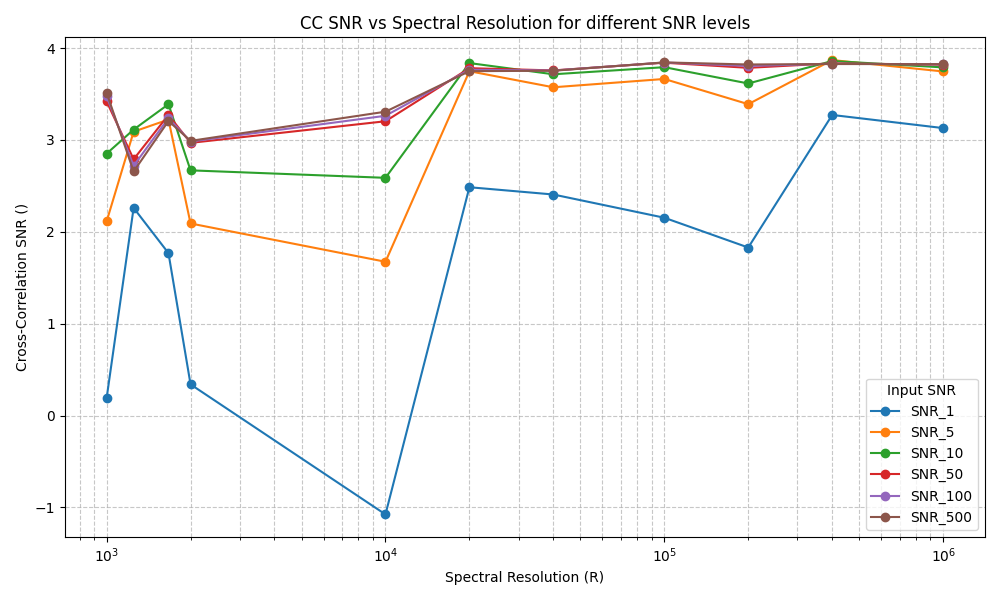

In [ ]:
df['resolution'] = pd.to_numeric(df['resolution'], errors='coerce')

# Sort by resolution for clean lines
df = df.sort_values(by='resolution')

# Plot
plt.figure(figsize=(10, 6))

for snr_label in df['snr'].unique():
    subset = df[df['snr'] == snr_label]
    plt.plot(subset['resolution'], subset['cc_snr'], 
             marker='o', label=snr_label)

plt.xscale('log')                    # usually better for resolution
plt.xlabel('Spectral Resolution (R)')
plt.ylabel('Cross-Correlation SNR (Cross-Correlation Value / Std Dev of Correlation)')
plt.title('CC SNR vs Spectral Resolution for different SNR levels')
plt.legend(title='Input SNR')
plt.grid(True, which='both', ls='--', alpha=0.7)


plt.tight_layout()
plt.show()

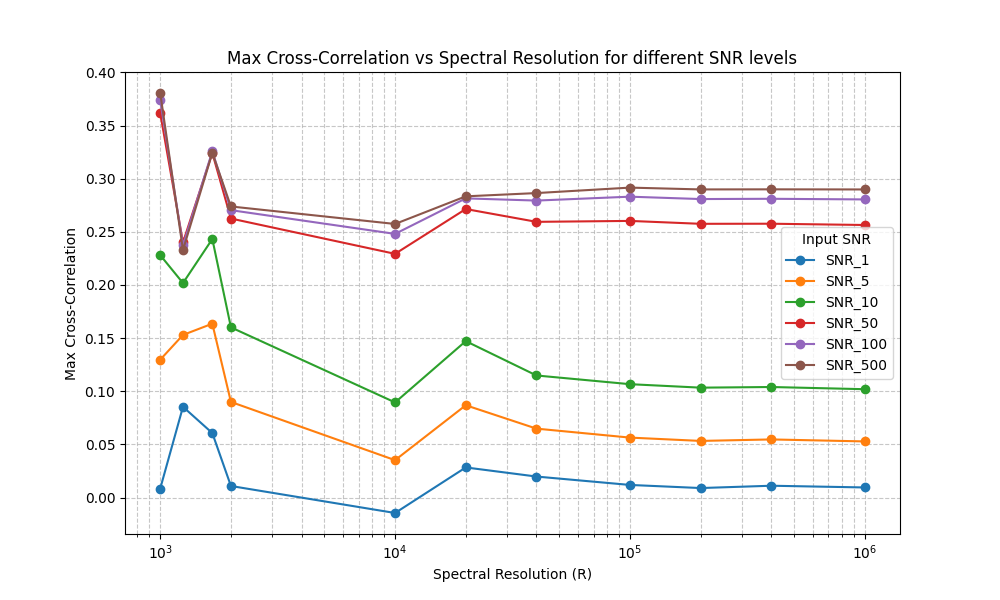

In [336]:
plt.figure(figsize=(10, 6))
for snr_label in df['snr'].unique():
    subset = df[df['snr'] == snr_label]
    plt.plot(subset['resolution'], subset['max_correlation'], 
             marker='o', label=snr_label)

plt.xscale('log')                    # usually better for resolution
plt.xlabel('Spectral Resolution (R)')
plt.ylabel('Max Cross-Correlation')
plt.title('Max Cross-Correlation vs Spectral Resolution for different SNR levels')
plt.legend(title='Input SNR')
plt.grid(True, which='both', ls='--', alpha=0.7)